# 🎸 01 – EDA: Gitár Akkord Felismerő Adathalmaz

**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár akkord felismerő szoftver gépi látással  
**Notebook célja:** Az adathalmaz teljes körű feltérképezése az előfeldolgozás tervezéséhez.

---

### Tartalomjegyzék
1. [Könyvtárak és konfiguráció](#1)
2. [Mappastruktúra és adathalmazok összegzése](#2)
3. [Osztályeloszlás és egyensúly vizsgálat](#3)
4. [Képméret, felbontás, képarány statisztikák](#4)
5. [Pixelintenzitás és csatorna-eloszlások](#5)
6. [Duplikátumok és sérült fájlok detektálása](#6)
7. [Fájlnév-forrás analízis (kamera vs. egyéb forrás)](#7)
8. [Példaképek osztályonként](#8)
9. [Train / Test szplit konzisztencia-ellenőrzés](#9)
10. [EDA összefoglaló és döntési pontok](#10)


<a id="1"></a>
## 1. Könyvtárak és konfiguráció

### 💾 Figure Saving Setup

Minden vizualizáció automatikusan mentésre kerül az `output/01_EDA/` mappába.

---

### Elméleti háttér: Python ML/CV könyvtárak

Ez a cella tölti be az EDA-hoz szükséges könyvtárakat. A főbb komponensek és szerepük:

- **`pandas`**: Táblázatos adatstruktúra (DataFrame). Az inventoryzáció, statisztikák és szűrési műveletek alapeszköze. Vektorizált számítások $O(n)$ időben.
- **`matplotlib` / `seaborn`**: Statisztikai vizualizáció. A seaborn magasabb szintű absztrakciókat kínál (violin, heatmap, pairplot).
- **`PIL` (Pillow)**: Képek betöltése, méret és csatornainformáció kiolvasása – `PIL.Image.open()` lazy loadingot végez.
- **`hashlib`**: Kriptográfiai hash-függvények (MD5, SHA-256) fájl-azonosításhoz és duplikátum-detektáláshoz.
- **`pathlib.Path`**: Fájlrendszer útvonalak platform-független kezeléséhez – az `os.path`-nél olvashatóbb API.
- **`sklearn`**: Gépi tanulási segédeszközök; itt a `StratifiedShuffleSplit` és `StandardScaler` lesz fontos.

**Miért szükséges az EDA?** Feltáró adatelemzés nélkül a modell tréningje *vak* – nem tudjuk, hogy milyen osztályegyensúllyal, képméretekkel és adatminőséggel dolgozunk. Az EDA eredményei közvetlen döntési alapot adnak a class weighting ($w_i \propto 1/n_i$), a normalizálás és az augmentáció beállításához.

In [ ]:
import os, hashlib, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── GPU/CUDA Support (Optional) ────────────────────────────────────────────
GPU_ARRAY_SUPPORT = False
CUDA_AVAILABLE = False

try:
    import cupy as cp
    GPU_ARRAY_SUPPORT = True
    print('🚀 CuPy: GPU-gyorsított array műveletek engedélyezve')
except ImportError:
    print('ℹ️  CuPy nincs telepítve (opcionális)')

# ── Elérési utak és output folder ──────────────────────────────────────────
NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = PROJECT_ROOT / 'data'
ALL_DIR   = DATA_ROOT / 'all'
TRAIN_DIR = DATA_ROOT / 'training'
TEST_DIR  = DATA_ROOT / 'test'

# Output folder setup
NOTEBOOK_NAME = Path(__file__).stem if '__file__' in dir() else '01_EDA'
OUTPUT_DIR = PROJECT_ROOT / 'output' / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'📁 Figures will be saved to: {OUTPUT_DIR}')

def save_figure(fig, name: str):
    """Save figure to output/notebook_name/ folder."""
    path = OUTPUT_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  ✅ Saved: {path.name}')
    return path

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f'\nProjekt gyökér: {PROJECT_ROOT}')
for d in [ALL_DIR, TRAIN_DIR, TEST_DIR, OUTPUT_DIR]:
    status = '✅ OK' if d.exists() else '❌ Nem található'
    print(f'{status}  {d}')


ℹ️  CuPy nincs telepítve (opcionális)
📁 Figures will be saved to: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/01_EDA

Projekt gyökér: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/training
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/test
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/01_EDA


<a id="2"></a>
## 2. Mappastruktúra és adathalmazok összegzése

### Elméleti háttér: Adatinventoryzáció

Az inventoryzáció célja minden kép metaadatának egységes táblázatos formába (DataFrame) gyűjtése. Ez az alaplépés teszi lehetővé az összes downstream elemzést.

**Fájlrendszer traversal:** A `pathlib.Path.rglob('*.{jpg,png,...}')` rekurzívan bejárja a mappastruktúrát. A mappa neve (**szülőmappa = osztálycímke**) a szabványos PyTorch `ImageFolder`-konvencióval megegyező struktúra.

**DataFrame mint EDA eszköz:** A `pd.DataFrame` kétdimenziós, heterogén adatstruktúra:
- Sorok: egyedi képek
- Oszlopok: `class`, `path`, `filename`, `size_kb`, (később) `split`

Az egységes reprezentáció lehetővé teszi, hogy a szplit-generálás, a statisztikák és a tréning ugyanarról az adatforrásról dolgozzanak – elkerülve az inkonzisztenciákat.

**Miért rögzítjük a fájlméretet?** A méreteloszlás (`size_kb`) utal a képminőségre (nagyon kis fájlok sérültek lehetnek), és segít a memória-tervezésben (batch size kiszámítása GPU-n).

In [ ]:
def build_inventory(root: Path) -> pd.DataFrame:
    """Minden képfájlhoz egy sor: osztály, elérési út, fájlméret (KB)."""
    columns = ['split', 'class', 'path', 'filename', 'size_kb']
    records = []
    if not root.exists():
        return pd.DataFrame(columns=columns)
    for cls_dir in sorted(root.iterdir()):
        if not cls_dir.is_dir():
            continue
        for p in cls_dir.iterdir():
            if p.suffix.lower() in IMAGE_EXTS:
                records.append({
                    'split': root.name,
                    'class': cls_dir.name,
                    'path': str(p),
                    'filename': p.name,
                    'size_kb': p.stat().st_size / 1024,
                })
    return pd.DataFrame(records, columns=columns)

df_all   = build_inventory(ALL_DIR)
df_train = build_inventory(TRAIN_DIR)
df_test  = build_inventory(TEST_DIR)
df_full  = pd.concat([df_all, df_train, df_test], ignore_index=True)

print('=== Adathalmaz összegzés ===')
print(f'all/     : {len(df_all):>4} kép  |  osztályok: {df_all["class"].nunique() if len(df_all) else 0}')
print(f'training/: {len(df_train):>4} kép  |  osztályok: {df_train["class"].nunique() if len(df_train) else 0}')
print(f'test/    : {len(df_test):>4} kép  |  osztályok: {df_test["class"].nunique() if len(df_test) else 0}')
print()

if df_full.empty:
    print('Nincs feldolgozható kép a data/al, data/training vagy data/test mappákban.')
else:
    summary = (df_full.groupby(['split', 'class'])
               .size().rename('count').reset_index()
               .pivot(index='class', columns='split', values='count')
               .fillna(0).astype(int))
    print(summary.to_string())


=== Adathalmaz összegzés ===
all/     :  297 kép  |  osztályok: 8
training/:  145 kép  |  osztályok: 7
test/    :  152 kép  |  osztályok: 7

split    all  test  training
class                       
A         33    18        15
B         56    19        37
C         47    18        29
D         44    27        17
E         31    24         7
F         49    24        25
G         22    22         0
No hand   15     0        15


<a id="3"></a>
## 3. Osztályeloszlás és egyensúly vizsgálat

### Elméleti háttér: Osztályegyensúly és imbalance kezelés

Ha az osztályok mérete eltér, a modell a domináns osztály felé torzul. Az egyensúlytalanság mértékét az **imbalance ratio** fejezi ki:

$$IR = \frac{n_{\max}}{n_{\min}}$$

ahol $n_{\max}$ a legtöbb és $n_{\min}$ a legkevesebb mintát tartalmazó osztály mérete. Ha $IR > 2$, class weighting vagy oversampling ajánlott.

**Shannon-entrópia** mint egyensúly-metrika: teljesen egyensúlyos $K$ osztály esetén $H = \log_2 K$ bit, egyensúlytalan esetén $H < \log_2 K$:

$$H = -\sum_{i=1}^{K} p_i \log_2 p_i$$

**Class weighting:** Az `nn.CrossEntropyLoss(weight=w)` súlyokat a következőképpen szokás beállítani:

$$w_i = \frac{N}{K \cdot n_i}$$

ahol $N$ az összes minta, $K$ az osztályok száma, $n_i$ az $i$-edik osztály mintaszáma. Így a ritkább osztályok nagyobb gradienssúlyt kapnak.

  ✅ Saved: 03_class_distribution.png


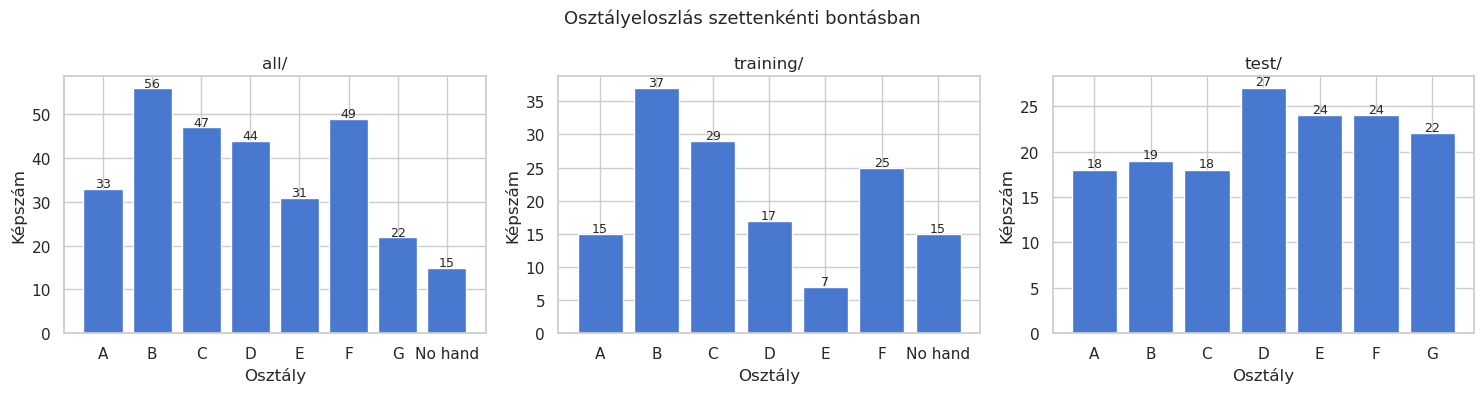


Imbalance ratio (all/): 3.73x
→ 1.5x alatt: kiegyensúlyozott | 2x felett: class weighting ajánlott | 3x felett: oversampling fontolóra veendő


In [ ]:
def plot_distribution(df: pd.DataFrame, title: str, ax):
    if df.empty:
        ax.set_title(f'{title} (nincs adat)')
        return
    counts = df['class'].value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(title)
    ax.set_ylabel('Képszám')
    ax.set_xlabel('Osztály')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha='center', fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
plot_distribution(df_all,   'all/',       axes[0])
plot_distribution(df_train, 'training/',  axes[1])
plot_distribution(df_test,  'test/',      axes[2])
plt.suptitle('Osztályeloszlás szettenkénti bontásban', fontsize=13)
plt.tight_layout()
save_figure(fig, '03_class_distribution')
plt.show()

# Imbalance metrikák az 'all' halmazon
if not df_all.empty:
    counts = df_all['class'].value_counts()
    imbalance_ratio = counts.max() / counts.min()
    print(f'\nImbalance ratio (all/): {imbalance_ratio:.2f}x')
    print('→ 1.5x alatt: kiegyensúlyozott | 2x felett: class weighting ajánlott | 3x felett: oversampling fontolóra veendő')


<a id="4"></a>
## 4. Képméret, felbontás, képarány statisztikák

### Elméleti háttér: Képméret és CNN kompatibilitás

A CNN modellek (MobileNet, EfficientNet, ResNet) **fix bemeneti méretet** várnak. A képeket a tréning előtt erre az egységes méretre kell skálázni.

**Aspect ratio** (képarány): $AR = W/H$. Ha az eredeti képarány nem egyezik a célméretével, a skálázás eltorzítja a képet. Megoldások:
- **Letterboxing**: Megtartja az arányokat, padding-gel tölti ki a hiányzó területet.
- **Center crop**: Az arány megtartása után a középső részt vágja ki.
- **Erőltetett átméretezés** (`transforms.Resize((224, 224))`): Gyors, de torzíthat.

**Miért 224×224?** Az ImageNet-en pretrained modellek (VGG, ResNet, MobileNet) erre a méretre vannak optimalizálva. Kisebb bemeneti méret gyorsítja a tréninget, de információt veszít; nagyobb méret pontosabb, de lassabb és több memóriát igényel.

**Felbontás-eloszlás vizsgálata** megmutatja, hogy szükség van-e padding vagy crop stratégiára, és hogy mennyit veszítünk az átméretezéssel a kisebb képeknél.

=== Képméret statisztikák (minta, n=150) ===
        width  height  aspect_ratio
count   150.0   150.0         150.0
mean   4640.0  3488.0           1.3
std       0.0     0.0           0.0
min    4640.0  3488.0           1.3
25%    4640.0  3488.0           1.3
50%    4640.0  3488.0           1.3
75%    4640.0  3488.0           1.3
max    4640.0  3488.0           1.3


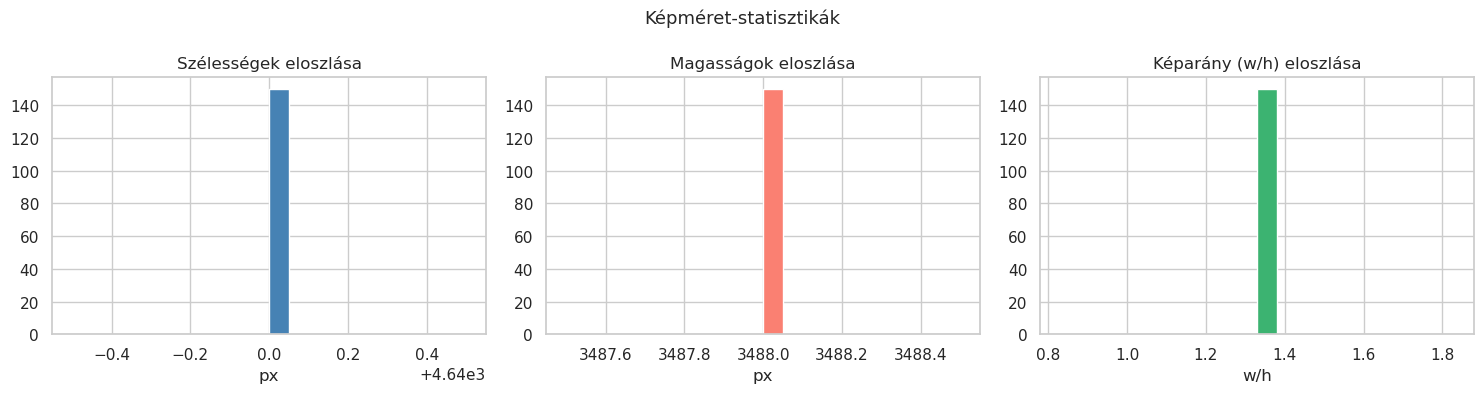

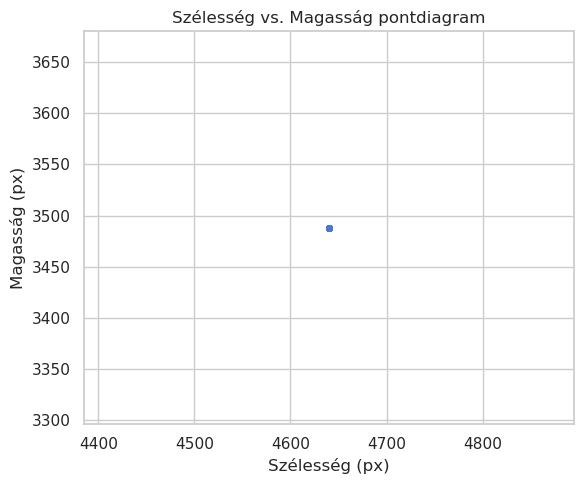


Pixel mód megoszlás: {'RGB': 150}


In [ ]:
def collect_image_stats(df: pd.DataFrame, sample_n: int = 150) -> pd.DataFrame:
    """Képméretek és felbontás kinyerése. GPU-n párhuzamosítható."""
    paths = df['path'].tolist() if 'path' in df.columns else []
    if len(paths) > sample_n:
        idx = rng.choice(len(paths), size=sample_n, replace=False)
        paths = [paths[i] for i in idx]

    rows = []
    for p in paths:
        try:
            with Image.open(p) as img:
                w, h = img.size
                mode = img.mode
                rows.append({'path': p, 'width': w, 'height': h,
                             'aspect_ratio': round(w/h, 3), 'mode': mode})
        except Exception:
            rows.append({'path': p, 'width': None, 'height': None,
                         'aspect_ratio': None, 'mode': None})
    return pd.DataFrame(rows, columns=['path', 'width', 'height', 'aspect_ratio', 'mode'])

stat_df = collect_image_stats(df_all, sample_n=150)
valid = stat_df.dropna(subset=['width', 'height', 'aspect_ratio']) if not stat_df.empty else stat_df

print('=== Képméret statisztikák (minta, n={}) ==='.format(len(valid)))
if valid.empty:
    print('Nincs feldolgozható kép a méretstatisztikákhoz.')
else:
    print(valid[['width','height','aspect_ratio']].describe().round(1).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(valid['width'],  bins=20, color='steelblue')
    axes[0].set_title('Szélességek eloszlása'); axes[0].set_xlabel('px')

    axes[1].hist(valid['height'], bins=20, color='salmon')
    axes[1].set_title('Magasságok eloszlása'); axes[1].set_xlabel('px')

    axes[2].hist(valid['aspect_ratio'], bins=20, color='mediumseagreen')
    axes[2].set_title('Képarány (w/h) eloszlása'); axes[2].set_xlabel('w/h')

    plt.suptitle('Képméret-statisztikák', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Scatter: width vs. height
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(valid['width'], valid['height'], alpha=0.5, s=15)
    ax.set_xlabel('Szélesség (px)'); ax.set_ylabel('Magasság (px)')
    ax.set_title('Szélesség vs. Magasság pontdiagram')
    plt.tight_layout()
    plt.show()

    # Pixel mód megoszlás
    print('\nPixel mód megoszlás:', dict(Counter(stat_df['mode'].dropna())))


<a id="5"></a>
## 5. Pixelintenzitás és RGB csatorna-eloszlások

### Elméleti háttér: Színtér és normalizálás

A CNN modellek bemenete általában normalizált pixelintenzitás $[0, 1]$ vagy $[-1, 1]$ tartományban. A normalizálás felgyorsítja a konvergenciát, mert az egyes csatornák hasonló skálán mozognak.

**RGB csatornák:** Minden kép három $[0, 255]$ értékű mátrixból áll (Vörös, Zöld, Kék). A csatornánkénti átlag ($\mu_c$) és szórás ($\sigma_c$) az adathalmaz jellemzői.

**ImageNet normalizáció** (a pretrained modellek elvárása):

$$\mu_{ImageNet} = [0.485,\ 0.456,\ 0.406], \quad \sigma_{ImageNet} = [0.229,\ 0.224,\ 0.225]$$

**Dataset-specifikus normalizáció**: Ha az adathalmaz (gitárképek) szín- és fényerő-eloszlása eltér az ImageNet-től, érdemes a saját $\mu$ és $\sigma$ értékeket számítani és `transforms.Normalize(mean, std)`-ben használni. Ez különösen akkor fontos, ha a képek homogén háttérrel rendelkeznek, vagy ha nem alkalmazunk transfer learninget.

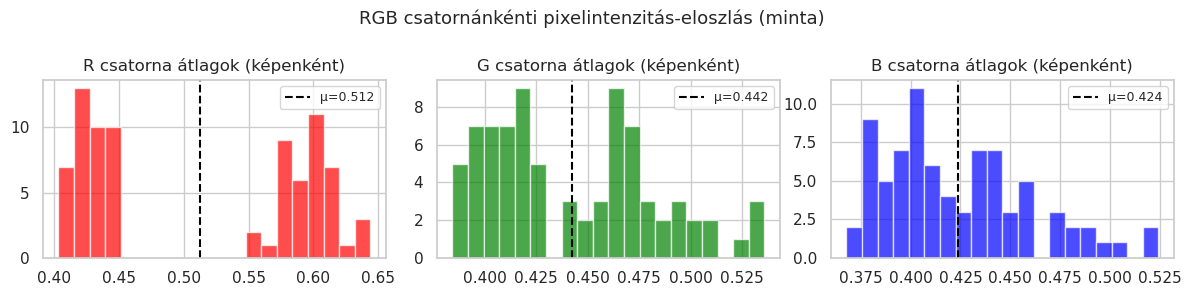

Becsült csatorna-átlagok (normalizáláshoz): {'R': 0.512, 'G': 0.442, 'B': 0.424}
Becsült csatorna-szórások: {'R': 0.087, 'G': 0.04, 'B': 0.036}

ImageNet referencia: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


In [ ]:
def channel_stats(df: pd.DataFrame, sample_n: int = 80):
    """R, G, B csatornánkénti átlag és szórás kiszámítása mintán."""
    paths = df['path'].tolist()
    if len(paths) > sample_n:
        idx = rng.choice(len(paths), size=sample_n, replace=False)
        paths = [paths[i] for i in idx]

    means = defaultdict(list)
    for p in paths:
        try:
            img = Image.open(p).convert('RGB').resize((128, 128))
            arr = np.array(img, dtype=np.float32) / 255.0
            
            # NumPy számítás (stabil, gyors)
            for i, c in enumerate(['R', 'G', 'B']):
                means[c].append(arr[:,:,i].mean())
        except:
            pass
    return means

ch = channel_stats(df_all, sample_n=80)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
colors = ['red', 'green', 'blue']
for ax, (c, col) in zip(axes, zip(['R','G','B'], colors)):
    ax.hist(ch[c], bins=20, color=col, alpha=0.7)
    ax.axvline(np.mean(ch[c]), color='black', linestyle='--', label=f'μ={np.mean(ch[c]):.3f}')
    ax.set_title(f'{c} csatorna átlagok (képenként)')
    ax.legend(fontsize=9)
plt.suptitle('RGB csatornánkénti pixelintenzitás-eloszlás (minta)', fontsize=13)
plt.tight_layout()
plt.show()

print('Becsült csatorna-átlagok (normalizáláshoz):', {c: round(float(np.mean(v)),3) for c,v in ch.items()})
print('Becsült csatorna-szórások:', {c: round(float(np.std(v)),3) for c,v in ch.items()})
print()
print('ImageNet referencia: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]')


<a id="6"></a>
## 6. Duplikátumok és sérült fájlok detektálása

### Elméleti háttér: Adatintegritás és train-test szivárgás

**MD5 hash:** Egy kriptográfiai hash-függvény, amely bármilyen méretű fájlból fix hosszú (128 bit = 32 hex karakter) ujjlenyomatot számít. Azonos fájltartalom → azonos hash (ütközés valószínűsége elhanyagolható).

$$MD5: \{0,1\}^* \rightarrow \{0,1\}^{128}$$

**Miért veszélyes a train-test átfedés?** Ha ugyanaz a kép szerepel a tréning- és a teszt-szettben, a modell "megjegyezheti" azt ($memorization$), és a teszt metrikák optimistán elfogultak lesznek. Ez **adatszivárgás** (*data leakage*).

**PIL.Image.verify():** Megnyitja és ellenőrzi a kép header-ét anélkül, hogy a teljes fájlt dekódolná. Ha a fájl sérült (csonkított, érvénytelen header), kivételt dob. Fontos a tréning-loop összeomlásának elkerüléséhez.

**Eljárás:** Minden fájlhoz kiszámítjuk az MD5-t, majd cross-referenciát futtatunk a train és test szetteken. Egyező hash = potenciális duplikátum.

In [ ]:
def file_md5(path: str) -> str:
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return ''

# Sérült képek
def find_corrupt(df: pd.DataFrame):
    corrupt = []
    for p in df['path']:
        try:
            Image.open(p).verify()
        except Exception as e:
            corrupt.append((p, str(e)))
    return corrupt

print('Sérült képek keresése (all/)...')
corrupt_list = find_corrupt(df_all) if not df_all.empty else []
print(f'  Talált sérült fájl: {len(corrupt_list)}')
for p, err in corrupt_list[:10]:
    print(f'  ⚠️  {p}: {err}')

# Duplikátumok MD5 alapján (train vs. test)
print('\nDuplikátum-keresés (training/ vs. test/)...')
if not df_train.empty and not df_test.empty:
    train_md5 = {f: file_md5(f) for f in df_train['path']}
    test_md5  = {f: file_md5(f) for f in df_test['path']}
    train_hashes = set(train_md5.values()) - {''}
    test_hashes  = set(test_md5.values()) - {''}
    overlap = train_hashes & test_hashes
    print(f'  Training képek MD5: {len(train_hashes)}')
    print(f'  Test képek MD5:     {len(test_hashes)}')
    print(f'  Átfedő (duplikált) képek: {len(overlap)}')
    if overlap:
        print('  ⚠️  FIGYELEM: train-test data leakage lehetséges!')
    else:
        print('  ✅ Nincs átfedés a training és test között.')
else:
    print('  (Hiányzó split mappák, kihagyjuk)')


Sérült képek keresése (all/)...
  Talált sérült fájl: 0

Duplikátum-keresés (training/ vs. test/)...
  Training képek MD5: 145
  Test képek MD5:     152
  Átfedő (duplikált) képek: 0
  ✅ Nincs átfedés a training és test között.


<a id="7"></a>
## 7. Fájlnév-forrás analízis

### Elméleti háttér: Adatforrás-heterogenitás

A fájlnevekből visszafejthető az adatgyűjtés forrása:
- `IMG_XXXX.jpg` / `DSC_XXXX.jpg` → **kamerás fénykép** (DSLR, telefon kamera)
- `1234567890.jpg` (Unix timestamp) → **alkalmazás által generált** (speciális felvételezési feltételek)

**Miért fontos ez?** A különböző adatforrások eltérő:
- képminőséget (felbontás, kompresszió, zajszint),
- megvilágítást és perspektívát,
- háttérkörnyezetet (stúdió vs. otthoni felvétel)
hoznak magukkal. Ha egyik forrás csak bizonyos osztályokban jelenik meg, **konfundáló változó** keletkezik: a modell tanulhat forrás-specifikus artifaktumokat a valódi akkord-jellemzők helyett.

**Ajánlás:** Ha a forrásarányok osztályonként eltérnek, augmentációval (RandomBrightness, RandomContrast) csökkentjük a forrás-specifikus jegyeket.

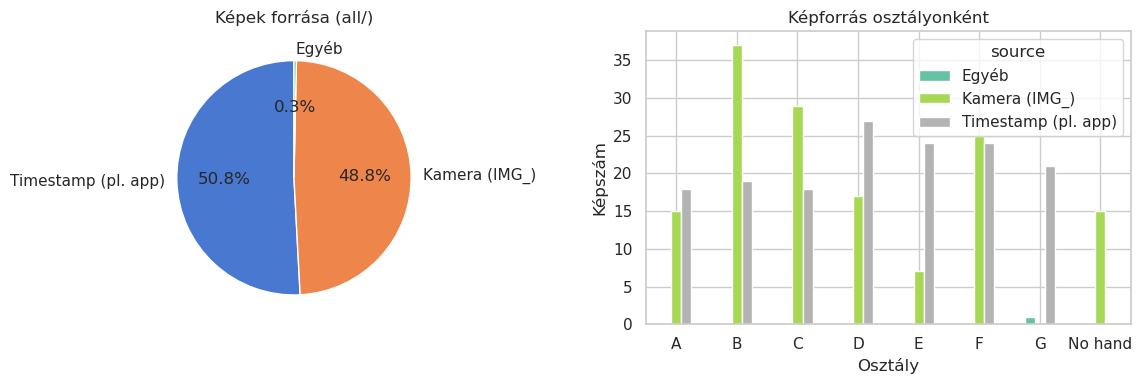

In [ ]:
def classify_filename(name: str) -> str:
    if name.upper().startswith('IMG_'):
        return 'Kamera (IMG_)'
    elif name[:4].isdigit():
        return 'Timestamp (pl. app)'
    else:
        return 'Egyéb'

df_all['source'] = df_all['filename'].apply(classify_filename) if not df_all.empty else None

if not df_all.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Pie
    src_counts = df_all['source'].value_counts()
    axes[0].pie(src_counts.values, labels=src_counts.index,
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Képek forrása (all/)')
    # Per-class
    cross = df_all.groupby(['class','source']).size().unstack(fill_value=0)
    cross.plot(kind='bar', ax=axes[1], colormap='Set2')
    axes[1].set_title('Képforrás osztályonként')
    axes[1].set_xlabel('Osztály')
    axes[1].set_ylabel('Képszám')
    axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()


<a id="8"></a>
## 8. Példaképek osztályonként (grid)

### Elméleti háttér: Vizuális sanity check

A vizuális ellenőrzés (*sanity check*) elengedhetetlen a gépi tanulási pipline első lépéseként. Automatikus feldolgozáskor felmerülő problémák:

- **Félrecímkézett képek**: A fájlnév nem egyezik a tényleges tartalommal (pl. "A" mappában "C" akkord).
- **Rossz minőségű képek**: Elmosódás, rossz vágás, szélső elforgatások.
- **Adataugmentáció tesztelése**: A grid megmutatja, hogy az augmentálás (flip, crop) nem ront-e a kép értelmezhetőségén.
- **Osztályon belüli variancia**: Látható-e elegendő variáció (különböző gitárok, szögek, megvilágítások)?

A vizuális ellenőrzés nem helyettesíti a kvantitatív metrikákat, de megmutatja az emberi szemmel is látható problémákat. Különösen a "No hand" osztálynál fontos, ahol az üres fogólapnak kell megjelennie.

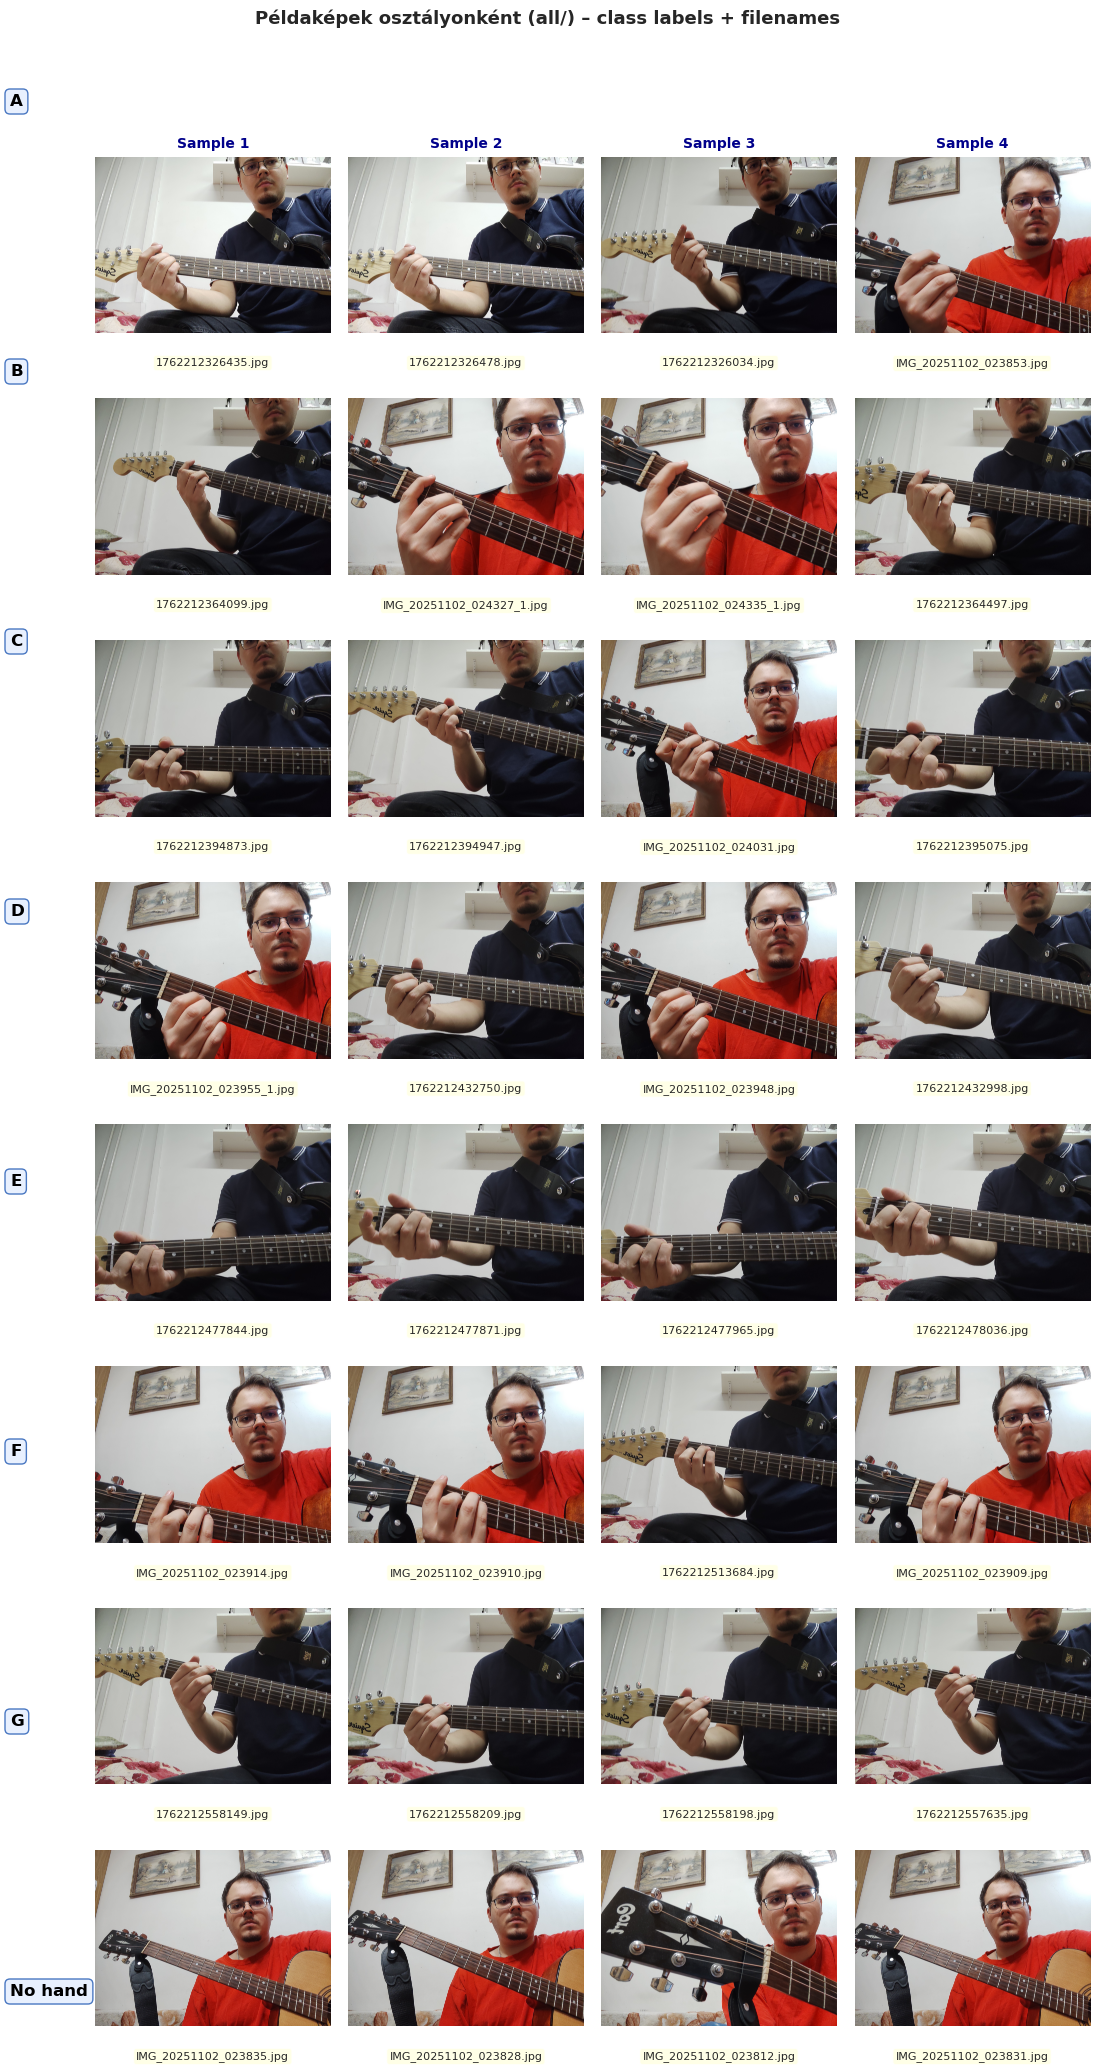

In [ ]:
def show_class_grid(root: Path, n_per_class: int = 4):
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    n_cls = len(classes)
    fig, axes = plt.subplots(n_cls, n_per_class,
                             figsize=(n_per_class * 2.8, n_cls * 2.7))
    if n_cls == 1:
        axes = axes.reshape(1, -1)

    # Column headers
    for col in range(n_per_class):
        axes[0, col].set_title(f'Sample {col + 1}', fontsize=10, fontweight='bold', color='darkblue')

    for row, cls in enumerate(classes):
        cls_dir = root / cls
        files = [p for p in cls_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
        if not files:
            for col in range(n_per_class):
                ax = axes[row][col]
                ax.axis('off')
            continue

        picked = [files[i] for i in rng.choice(len(files), size=min(n_per_class, len(files)), replace=False)]
        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis('off')
            if col < len(picked):
                try:
                    img_path = picked[col]
                    ax.imshow(Image.open(img_path))
                    filename = img_path.name
                    ax.text(
                        0.5, -0.14, filename,
                        ha='center', va='top',
                        transform=ax.transAxes,
                        fontsize=8, wrap=True,
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='lightyellow', alpha=0.75)
                    )
                except Exception:
                    ax.set_facecolor('#ffdddd')
                    ax.text(0.5, 0.5, '❌ Hiba', ha='center', va='center',
                            transform=ax.transAxes, fontsize=10, color='red')

    # Class labels as row headers on the left side
    for row, cls in enumerate(classes):
        y = 1 - (row + 0.5) / n_cls
        fig.text(
            0.02, y, cls,
            ha='left', va='center',
            fontsize=12, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f0fe', edgecolor='#4a78c2')
        )

    plt.suptitle('Példaképek osztályonként (all/) – class labels + filenames', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0.08, 0.02, 1, 0.95])
    plt.show()

show_class_grid(ALL_DIR, n_per_class=4) if ALL_DIR.exists() else None


<a id="9"></a>
## 9. Train / Test szplit konzisztencia-ellenőrzés

### Elméleti háttér: Train-test szplit integritás

**Mit ellenőrzünk?**
1. Minden osztály jelen van-e mindkét szettben?
2. Van-e átfedés (duplikátum) a train és test szett között?
3. Az osztályarányok hasonlóak-e mindkét szettben?

**Jellemzők nélküli osztályok kezelése:** Ha egy osztály csak a tréning-szettben szerepel ("No hand"), a modell nem tanul érvényes döntési határt ehhez az osztályhoz. Ha csak a teszt-szettben szerepel ("G"), nem értékelhető ki érvényesen.

**Stratified split szükségessége:** A véletlenszerű szplit kis adathalmaznál ($n < 300$) veszélyes, mert osztályok kieshetnek. A `StratifiedShuffleSplit` garantálja, hogy minden osztályból azonos arányban kerüljenek minták mindkét szettbe:

$$\forall i: \frac{n_i^{test}}{n_i^{train}} \approx \text{const}$$

Az esetleges inkonzisztenciák **azelőtt** kell javítani, hogy a feature extraction vagy tréning elkezdődne.

In [ ]:
if not df_train.empty and not df_test.empty:
    train_classes = set(df_train['class'].unique())
    test_classes  = set(df_test['class'].unique())
    all_classes   = set(df_all['class'].unique()) if not df_all.empty else train_classes

    print('=== Osztály-konzisztencia ===')
    print(f'all/ osztályok:      {sorted(all_classes)}')
    print(f'training/ osztályok: {sorted(train_classes)}')
    print(f'test/ osztályok:     {sorted(test_classes)}')

    only_train = train_classes - test_classes
    only_test  = test_classes - train_classes
    if only_train: print(f'⚠️  Csak training-ben: {only_train}')
    if only_test:  print(f'⚠️  Csak test-ben: {only_test}')
    if not only_train and not only_test:
        print('✅ Mindkét szettben ugyanazok az osztályok.')

    # Train/test arányok osztályonként
    t_cnt = df_train['class'].value_counts().rename('train')
    v_cnt = df_test['class'].value_counts().rename('test')
    ratio_df = pd.concat([t_cnt, v_cnt], axis=1).fillna(0).astype(int)
    ratio_df['total'] = ratio_df['train'] + ratio_df['test']
    ratio_df['test_%'] = (ratio_df['test'] / ratio_df['total'] * 100).round(1)
    print()
    print(ratio_df.to_string())
    print()
    print('⚠️  Figyelem: a training/ mappában NEM található külön validation split.')
    print('    Javaslat: scikit-learn StratifiedShuffleSplit(test_size=0.2) a training/-on belül.')


=== Osztály-konzisztencia ===
all/ osztályok:      ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']
training/ osztályok: ['A', 'B', 'C', 'D', 'E', 'F', 'No hand']
test/ osztályok:     ['A', 'B', 'C', 'D', 'E', 'F', 'G']
⚠️  Csak training-ben: {'No hand'}
⚠️  Csak test-ben: {'G'}

         train  test  total  test_%
class                              
B           37    19     56    33.9
C           29    18     47    38.3
F           25    24     49    49.0
D           17    27     44    61.4
A           15    18     33    54.5
No hand     15     0     15     0.0
E            7    24     31    77.4
G            0    22     22   100.0

⚠️  Figyelem: a training/ mappában NEM található külön validation split.
    Javaslat: scikit-learn StratifiedShuffleSplit(test_size=0.2) a training/-on belül.


<a id="10"></a>
## 10. EDA összefoglaló és döntési pontok

| # | Kérdés | Ajánlás |
|---|--------|---------|
| 1 | **Célméret normalizálás** | 224×224 px (MobileNetV2-kompatibilis, CPU-n is gyors) |
| 2 | **Színcsatornák** | RGB megtartása (a kézszínek informatívak); szürkeárnyalatos opció ha nincs elegendő adat |
| 3 | **Normalizáció** | Saját mean/std értékek (lásd 5. cella outputja) vs. ImageNet default; kisebb adathalmaznál az ImageNet értékek is elfogadhatók |
| 4 | **Class weighting** | Ha imbalance ratio > 2x: `class_weight='balanced'` scikit-learnben |
| 5 | **Augmentáció** | RandomHorizontalFlip, ColorJitter, RandomRotation(±15°) – különösen az alulreprezentált osztályoknak |
| 6 | **Validation split** | StratifiedShuffleSplit(test_size=0.2) a training/ halmazon belül; a test/ holdout marad |
| 7 | **Sérült/duplikált képek** | Kiszűrés a preprocessing lépésben, logolás |
| 8 | **Fájlnév-forrás egyensúly** | Ha az IMG_ és timestamp képek aránya osztályonként nagyon eltér, az augmentáció ezt is kompenzálhatja |

### Következő lépés: `02_preprocessing.ipynb`
- Validation split létrehozása
- Augmentációs pipeline implementálása
- MediaPipe kézkulcspont-kinyerés és feature CSV generálása
